# **Machine Learning in Action:<br>Step-by-Step Fruit & Vegetable Image Recognition**

# **By: Ir. Erlinda Gilberta Wibawa, S.T., M.T.**
## **_(A Lecturer in Logistics Engineering,<br>Universitas Katolik Santo Agustinus Hippo,<br>West Kalimantan, Indonesia)_**

[Email: erlindagilbertaw@gmail.com](mailto:erlindagilbertaw@gmail.com)  
[Instagram: @erlinda_gilberta](https://www.instagram.com/erlinda_gilberta/?hl=en)

## LIBRARIES PREPARATION

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

## 1. TRAIN THE MODEL

### 1.1. TRAINING DATASET PREPARATION

In [23]:
training_set = tf.keras.utils.image_dataset_from_directory(
    r'D:\PROJECT\MachineLearning\train',
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(64,64),
    shuffle=True
)

Found 3115 files belonging to 36 classes.


### 1.2. VALIDATION DATASET PREPARATION

In [26]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    r'D:\PROJECT\MachineLearning\validation',
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(64,64),
    shuffle=True
)

Found 351 files belonging to 36 classes.


### 1.3. BUILD THE MODEL

In [31]:
cnn = tf.keras.models.Sequential()

#BUILD THE CONCOLUTION LAYERS
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[64,64,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Dropout(0.25))

cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Dropout(0.25))

cnn.add(tf.keras.layers.Flatten())

cnn.add(tf.keras.layers.Dense(units=512,activation='relu'))

cnn.add(tf.keras.layers.Dense(units=256,activation='relu'))

cnn.add(tf.keras.layers.Dropout(0.5)) #To avoid overfitting

cnn.add(tf.keras.layers.Dense(units=36,activation='softmax')) #Output Layer


### 1.4. COMPILING & TRAINING PHASE

In [33]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
cnn.summary()

training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=32)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 62, 62, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 31, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,629,188 (25.29 MB)

 Trainable params: 6,629,188 (25.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/32
98/98 ━━━━━━━━━━━━━━━━━━━━ 33s 313ms/step - accuracy: 0.0372 - loss: 6.4355 - val_accuracy: 0.0741 - val_loss: 3.4098
Epoch 2/32
98/98 ━━━━━━━━━━━━━━━━━━━━ 22s 214ms/step - accuracy: 0.0623 - loss: 3.4583 - val_accuracy: 0.1140 - val_loss: 3.4618
Epoch 3/32
98/98 ━━━━━━━━━━━━━━━━━━━━ 28s 277ms/step - accuracy: 0.0716 - loss: 3.3846 - val_accuracy: 0.1197 - val_loss: 3.1444
Epoch 4/32
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 207ms/step - accuracy: 0.0992 - loss: 3.2375 - val_accuracy: 0.1709 - val_loss: 2.9638
Epoch 5/32
98/98 ━━━━━━━━━━━━━━━━━━━━ 24s 244ms/step - accuracy: 0.0982 - loss: 3.1903 - val_accuracy: 0.2080 - val_loss: 2.8033
Epoch 6/32
98/98 ━━━━━━━━━━━━━━━━━━━━ 28s 284ms/step - accuracy: 0.1535 - loss: 3.0324 - val_accuracy: 0.3048 - val_loss: 2.5685
Epoch 7/32
98/98 ━━━━━━━━━━━━━━━━━━━━ 29s 298ms/step - accuracy: 0.1660 - loss: 2.9232 - val_accuracy: 0.3447 - val_loss: 2.3516
Epoch 8/32
98/98 ━━━━━━━━━━━━━━━━━━━━ 31s 317ms/step - accuracy: 0.1965 - loss: 2.7960 - val_accu

### 1.5. MODEL EVALUATION

In [35]:
#Training set Accuracy
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

#Validation set Accuracy
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

98/98 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.9827 - loss: 0.0693
Training accuracy: 0.9826645255088806
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.9544 - loss: 0.3250
Validation accuracy: 0.9544159770011902


### 1.6. SAVE THE MODEL

In [39]:
cnn.save('trained_model.h5')

# Return dictionary of history
training_history.history

# Recording history in JSON
import json

with open('training_hist.json', 'w') as f:
    json.dump(training_history.history, f)  # <-- must be indented

print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


### 1.7. MODEL ACCURACY CALCULATON

Validation set Accuracy: 95.44159770011902 %


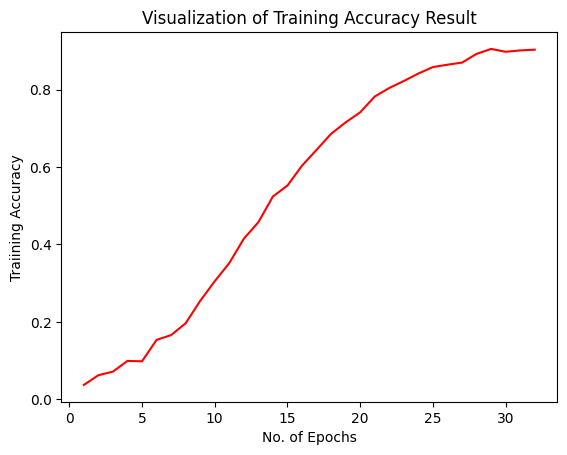

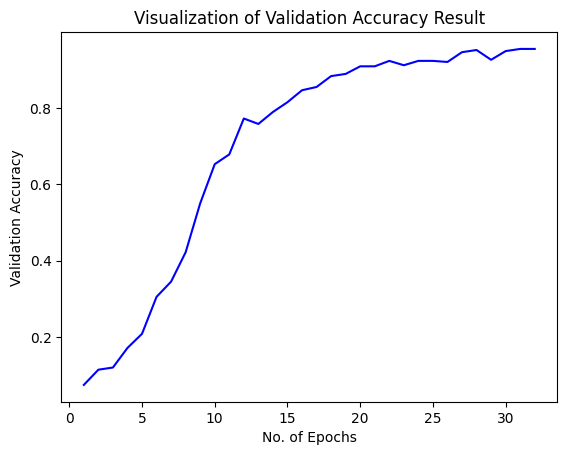

In [40]:
#Accuracy Calculation
print("Validation set Accuracy: {} %".format(training_history.history['val_accuracy'][-1]*100))

#TRAINING Accuracy Visualization
epochs = [i for i in range(1,33)]
plt.plot(epochs,training_history.history['accuracy'],color='red')
plt.xlabel('No. of Epochs')
plt.ylabel('Traiining Accuracy')
plt.title('Visualization of Training Accuracy Result')
plt.show()

#VALIDATION Accuracy Visualization
plt.plot(epochs,training_history.history['val_accuracy'],color='blue')
plt.xlabel('No. of Epochs')
plt.ylabel('Validation Accuracy')
plt.title('Visualization of Validation Accuracy Result')
plt.show()

## 2. TEST THE MODEL

### 2.1. TESTING DATASET PREPARATION

In [78]:
testing_set = tf.keras.utils.image_dataset_from_directory(
    r'D:\PROJECT\MachineLearning\test',
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(64,64),
    shuffle=True
)

Found 359 files belonging to 36 classes.


### 2.2. MODEL LOADING

In [79]:
cnn = tf.keras.models.load_model('D:\PROJECT\MachineLearning/trained_model.h5')

### 2.3. TEST THE MODEL

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
[[8.5752776e-12 1.4673013e-19 2.8133415e-14 5.8244368e-11 1.2712851e-23
  2.1656378e-11 3.5157383e-12 4.9437920e-16 1.4326902e-12 8.6777136e-17
  4.8128955e-26 6.9486653e-14 1.8755268e-18 8.7826117e-18 5.9361128e-17
  6.2391204e-19 1.1136687e-20 1.3537977e-15 2.6395719e-20 2.5900419e-14
  2.1731851e-11 4.8190032e-11 5.9301184e-12 7.1366768e-17 9.1884631e-23
  3.8905460e-18 1.0000000e+00 6.6683231e-17 4.9874703e-17 1.9118179e-18
  4.0160423e-23 1.8427002e-17 3.5789260e-11 3.3008977e-08 1.9860007e-15
  1.0600822e-14]]
26


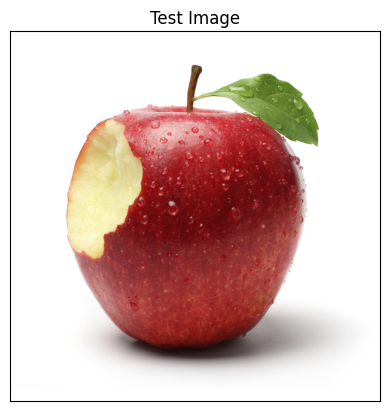

It's a pomegranate


In [83]:
image_path = r'D:\PROJECT\MachineLearning\test\pomegranate\Image_9.jpg'
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(64,64))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr])  # Convert single image to a batch.
predictions = cnn.predict(input_arr)

print(predictions)

result_index = np.argmax(predictions) #Return index of max element
print(result_index)

# Displaying the image 
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

#Named the Image Prediction
print("It's a {}".format(testing_set.class_names[result_index]))